In [ ]:
from IPython.display import display, HTML

# ---------------------------------------------------------
# UI Tweak: Force Scrollable Outputs
# ---------------------------------------------------------
# This ensures that long logs or large prints don't take up 
# the entire screen. They will be contained in a 400px window.
display(HTML("""
<style>
.output_wrapper, .output {
    height:auto !important;
    max-height: 400px; /* Adjust this value to change window size */
}
.output_scroll {
    box-shadow:none !important;
    webkit-box-shadow:none !important;
}
</style>
"""))

# Module 03 — Safety-Aware Contextual Bandits (The Simulation)
**Objective:** Comparative evaluation of 5 pricing policies using Counterfactual Policy Evaluation (CPE).

**The Competitors:**
1. **Thompson Sampling:** Bayesian exploration (Primary).
2. **Bayesian UCB:** Optimistic deterministic selection (Conservative).
3. **Model Uncertainty TS:** Robustness check using ensemble simulation.
4. **Greedy Confidence:** Risk-adjusted exploitation (Revenue - Lambda*Risk).
5. **Epsilon Greedy:** Randomized baseline.

**The Governor:**
All policies are subject to the `SafetyGovernor` (via Adapter), which enforces:
- Floor constraints ($75)
- Economic Monotonicity (via TF Lattice)
- Anti-Hallucination checks

In [2]:
import sys
import os
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

# --- Reproducibility ---
np.random.seed(42)

# --- Path Setup ---
try:
    SCRIPT_DIR = Path(__file__).parent
except NameError:
    SCRIPT_DIR = Path.cwd()
sys.path.append(os.path.abspath(".."))

# --- Imports ---
from pricing_engine.data_loader import load_and_clean_seattle_data
from pricing_engine.demand_model import DemandModel
from pricing_engine.safety import SafetyConfig
from pricing_engine.pricing_strategy import (
    BanditDecision,
    ModelRole,
    StrategyGovernorAdapter,
    ThompsonSamplingPolicy,
    BayesianUCBPolicy,
    ModelUncertaintyTSPolicy,
    GreedyConfidencePolicy,
    EpsilonGreedyPolicy
)

# --- Logging ---
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger("BanditSim")


## 1. Load The "Brain" (Module 02 Artifacts)

In [ ]:
import tensorflow as tf
import tensorflow_lattice as tfl
import joblib

ARTIFACT_DIR = "../demand_artifacts"
MODELS = {}

logger.info("🔌 Loading Certified Demand Models...")

# --- Smart Loader for Keras Models (Handles Moved Folders) ---
def load_keras_robust(role, base_path):
    """
    Manually reconstructs KerasDemandModel when paths are broken.
    Assumes standard structure: 
       base_path (Pointer File)
       base_path + "_artifacts" (Folder)
    """
    # 1. Deduce Artifact Directory (Ignore file content, trust strict naming convention)
    # If base_path is ".../TF_Lattice.pkl", artifact_dir is ".../TF_Lattice.pkl_artifacts"
    artifact_dir = base_path + "_artifacts"
    
    if not os.path.exists(artifact_dir):
        # Fallback: maybe the extension isn't in the folder name?
        artifact_dir = base_path.replace(".pkl", "") + "_artifacts"
        if not os.path.exists(artifact_dir):
            raise FileNotFoundError(f"Could not find artifact folder for {role} at {artifact_dir}")

    logger.info(f"   🔎 Found artifacts for {role} at: {artifact_dir}")

    # 2. Load the Wrapper (Metadata)
    wrapper_path = os.path.join(artifact_dir, "wrapper.pkl")
    try:
        wrapper = joblib.load(wrapper_path)
    except Exception as e:
        raise ValueError(f"Failed to load wrapper for {role}: {e}")

    # 3. Load the Keras Model (Weights)
    keras_model_path = os.path.join(artifact_dir, "keras_model")
    try:
        # TFLattice requires custom objects context
        with tfl.custom_objects_scope():
            keras_model = tf.keras.models.load_model(keras_model_path)
    except Exception as e:
        # Fallback for standard Keras/DeepFM without Lattice scope
        keras_model = tf.keras.models.load_model(keras_model_path)

    # 4. Re-attach
    wrapper.model = keras_model
    return wrapper

# --- Main Loading Loop ---
model_map = {
    ModelRole.UNCERTAINTY: "HierarchicalBayes.pkl",
    ModelRole.MEAN: "LGBM_Tweedie.pkl",
    ModelRole.SAFETY: "TF_Lattice.pkl",
    ModelRole.RESEARCH: "DeepFM.pkl"
}

for role, filename in model_map.items():
    path = os.path.join(ARTIFACT_DIR, filename)
    
    try:
        # Strategy A: Try Standard Joblib (Works for LGBM/Bayes)
        try:
            MODELS[role] = DemandModel.load(path)
            logger.info(f"   ✅ Loaded {role} (Standard Joblib)")
            continue
        except:
            pass # Fall through to Strategy B

        # Strategy B: Robust Keras Re-assembly (Works for Lattice/DeepFM)
        if "Lattice" in role or "DeepFM" in role:
            MODELS[role] = load_keras_robust(role, path)
            logger.info(f"   ✅ Loaded {role} (Robust Keras Loader)")
        else:
            # If it wasn't Keras and failed Joblib, it's a real error
            raise ValueError("Joblib load failed for non-Keras model")
            
    except Exception as e:
        logger.error(f"   ❌ Failed to load {role}: {e}")
        if role == ModelRole.MEAN: # Critical
            raise

if not MODELS:
    raise ValueError("No models found! Check your demand_artifacts folder.")

2026-01-10 00:53:56,666 | INFO | 🔌 Loading Certified Demand Models...
2026-01-10 00:53:56,679 | INFO |    ✅ Loaded HierarchicalBayes (Standard Joblib)
2026-01-10 00:53:56,703 | INFO |    ✅ Loaded LGBM_Tweedie (Standard Joblib)
2026-01-10 00:53:56,703 | INFO |    🔎 Found artifacts for TF_Lattice at: ../demand_artifacts\TF_Lattice.pkl_artifacts
2026-01-10 00:53:58,643 | INFO |    ✅ Loaded TF_Lattice (Robust Keras Loader)
2026-01-10 00:53:58,643 | INFO |    🔎 Found artifacts for DeepFM at: ../demand_artifacts\DeepFM.pkl_artifacts
2026-01-10 00:53:59,406 | INFO |    ✅ Loaded DeepFM (Robust Keras Loader)


## 2. Load The "World" (Test Data)

In [4]:

# 1. Load Data (Same as Module 02)
CALENDAR_PATH = "../data/calendar.csv"
LISTINGS_PATH = "../data/listings.csv"

logger.info("🌍 Regenerating Simulation Environment...")
df_raw = load_and_clean_seattle_data(CALENDAR_PATH, LISTINGS_PATH)

# 2. Process Features (Must match Module 02 exactly)
weekly_df = (
    df_raw
    .assign(week_date=pd.to_datetime(df_raw["date"]).dt.to_period("W").dt.start_time)
    .groupby(["listing_id", "week_date"])
    .agg({
        "is_booked_proxy": "max",
        "price": "mean",
        "accommodates": "first",
        "bedrooms": "first",
        "bathrooms": "first",
        "neighborhood": "first"
    }).reset_index()
    .rename(columns={"is_booked_proxy": "is_booked", "price": "avg_price"})
)

# Feature Engineering
weekly_df["log_price"] = np.log1p(weekly_df["avg_price"])
weekly_df["week_of_year"] = weekly_df["week_date"].dt.isocalendar().week.astype(int)
weekly_df["month"] = weekly_df["week_date"].dt.month
weekly_df["neighborhood"] = weekly_df["neighborhood"].fillna("Unknown").astype("category")
for c in ["accommodates", "bedrooms", "bathrooms"]:
    weekly_df[c] = weekly_df[c].fillna(weekly_df[c].median())

# 3. Create Holdout Set (Simulation Split)
SPLIT_DATE = "2016-09-01"
simulation_df = weekly_df[weekly_df["week_date"] >= SPLIT_DATE].copy().reset_index(drop=True)

logger.info(f"   ✅ Simulation Set: {len(simulation_df):,} contexts (Post {SPLIT_DATE})")


2026-01-10 00:53:59,426 | INFO | 🌍 Regenerating Simulation Environment...
2026-01-10 00:53:59,426 | INFO | Loading raw data...
2026-01-10 00:54:02,750 | INFO | Total rows loaded: 1393570
2026-01-10 00:54:02,757 | INFO | Action observed rate: 67.06%
2026-01-10 00:54:02,757 | INFO | Exposure rate: 67.06%
2026-01-10 00:54:02,763 | INFO | Booked proxy rate: 32.94%
2026-01-10 00:54:03,340 | INFO |    ✅ Simulation Set: 68,724 contexts (Post 2016-09-01)


## 3. Initialize The 5-Bandit Portfolio

**Architectural Note:**
Prices are discretized to a finite action space for tractability; continuous pricing would require gradient-based or Bayesian optimization methods (e.g., GP-UCB), which are computationally expensive for high-frequency serving.

In [5]:
# Define Action Space (Allowed Prices)
ACTION_SPACE = [80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 180.0, 190.0, 200.0]

# Initialize Governor (Adapter wrapper around safety.py)
# We set strict Lattice parameters to catch hallucinations
gov_config = SafetyConfig(
    min_price_global=75.0,
    lattice_hallucination_thresh=3.0,
    lattice_min_prob=0.005
)
governor = StrategyGovernorAdapter(config=gov_config)

# Initialize Policies
policies = [
    ThompsonSamplingPolicy(),                     # B1: Bayesian
    BayesianUCBPolicy(ucb_scale=1.0),             # B2: Optimistic
    ModelUncertaintyTSPolicy(),                   # B3: Robust
    GreedyConfidencePolicy(penalty_scale=0.5),    # B4: Risk-Averse
    EpsilonGreedyPolicy(epsilon=0.1)              # B5: Baseline
]

logger.info(f"⚔️  initialized {len(policies)} policies.")


2026-01-10 00:54:03,353 | INFO | ⚔️  initialized 5 policies.


## 4. The Simulation Loop (with Regret & Oracle)

**Methodology Note:**
We use **Expected Revenue** ($Price \times \hat{P}_{oracle}$) rather than stochastic Bernoulli outcomes to reduce simulation variance and focus on policy quality.

**The Oracle:**
We use `HierarchicalBayes` as the Ground Truth Oracle to calculate "Regret" (how much revenue we missed vs. the optimal price).


In [6]:
SIMULATION_SAMPLES = 3000 
results = []

stream = simulation_df.sample(n=min(SIMULATION_SAMPLES, len(simulation_df)), random_state=42)
oracle_model = MODELS[ModelRole.UNCERTAINTY]

logger.info("🚀 Starting Simulation Loop...")

for idx, context in tqdm(stream.iterrows(), total=len(stream)):
    
    # --- 1. Oracle Calculation (The Perfect Decision) ---
    # What was the theoretical MAX revenue for this context?
    oracle_probe = policies[0]._make_probe(context, ACTION_SPACE, oracle_model)
    oracle_probs = oracle_model.predict(oracle_probe)
    oracle_revenues = np.array(ACTION_SPACE) * oracle_probs
    oracle_best_rev = np.max(oracle_revenues)
    
    for policy in policies:
        # A. Ask Policy
        decision = policy.select_price(context, ACTION_SPACE, MODELS)
        
        # B. Apply Safety
        final_decision = governor.govern(decision, MODELS, context)
        
        # C. Calculate Reward (Expected Value)
        # Re-probe the Oracle for the SPECIFIC price chosen by the bandit
        eval_probe = pd.DataFrame([context])
        eval_probe["avg_price"] = final_decision.price
        eval_probe["log_price"] = np.log1p(final_decision.price)
        if hasattr(oracle_model, "cat_cols"):
             for c in oracle_model.cat_cols:
                 if c in eval_probe.columns: eval_probe[c] = eval_probe[c].astype("category")
        
        true_prob_est = oracle_model.predict(eval_probe)[0]
        simulated_revenue = final_decision.price * true_prob_est
        
        # D. Calculate Regret
        regret = max(0, oracle_best_rev - simulated_revenue)
        
        # E. Normalize Regret (Fair comparison across high/low value listings)
        norm_regret = regret / (oracle_best_rev + 1e-9)
        
        # F. Log
        results.append({
            "round": idx,
            "policy": policy.name,
            "listing_id": context["listing_id"],
            "selected_price": final_decision.price,
            "revenue": simulated_revenue,
            "regret": regret,
            "norm_regret": norm_regret,
            "prob_predicted": final_decision.prob_book,
            "prob_actual_est": true_prob_est,
            "was_overridden": final_decision.was_overridden,
            "uncertainty": final_decision.uncertainty_proxy
        })


2026-01-10 00:54:03,377 | INFO | 🚀 Starting Simulation Loop...
  0%|          | 0/3000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 27ms/step


  0%|          | 1/3000 [00:00<39:57,  1.25it/s]

1/1 [==============================] - 0s 24ms/step


  0%|          | 2/3000 [00:01<36:16,  1.38it/s]

...

100%|█████████▉| 2998/3000 [24:36<00:01,  1.91it/s]

1/1 [==============================] - 0s 22ms/step


100%|█████████▉| 2999/3000 [24:36<00:00,  1.95it/s]

1/1 [==============================] - 0s 25ms/step


100%|██████████| 3000/3000 [24:37<00:00,  2.03it/s]


In [9]:
results

[{'round': 67718,
  'policy': 'ThompsonSampling',
  'listing_id': 10132385,
  'selected_price': 138.95,
  'revenue': 13.237919546273108,
  'regret': 5.615673943226856,
  'norm_regret': 0.29785695475276414,
  'prob_predicted': 0.07124606152886215,
  'prob_actual_est': 0.09527110144852903,
  'was_overridden': True,
  'uncertainty': 0.05},
 {'round': 67718,
  'policy': 'BayesianUCB',
  'listing_id': 10132385,
  'selected_price': 199.72,
  'revenue': 18.82796628057238,
  'regret': 0.025627208927584633,
  'norm_regret': 0.0013592745033193692,
  'prob_predicted': 0.05761125301597316,
  'prob_actual_est': 0.0942718119395773,
  'was_overridden': True,
  'uncertainty': 0.009426796744749983},
 {'round': 67718,
  'policy': 'ModelUncertaintyTS',
  'listing_id': 10132385,
  'selected_price': 119.91,
  'revenue': 11.472871448290944,
  'regret': 7.380722041209021,
  'norm_regret': 0.39147561152880767,
  'prob_predicted': 0.10107910665868015,
  'prob_actual_est': 0.09567902133509251,
  'was_overridden

## 5. Analysis & Visualization

c:\Users\99sma\Desktop\Dynamic Pricing Engine\pe\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


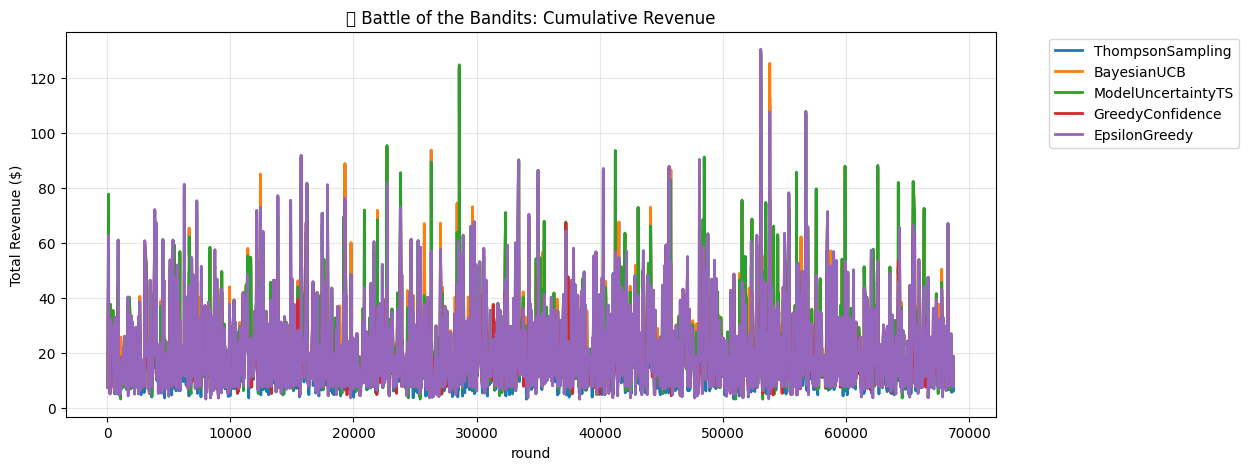

c:\Users\99sma\Desktop\Dynamic Pricing Engine\pe\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


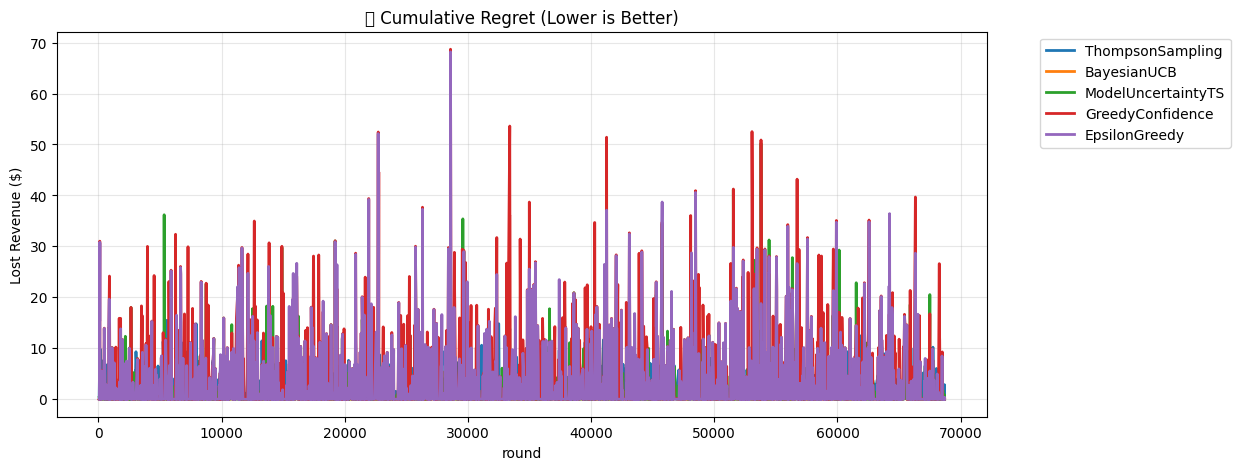

c:\Users\99sma\Desktop\Dynamic Pricing Engine\pe\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


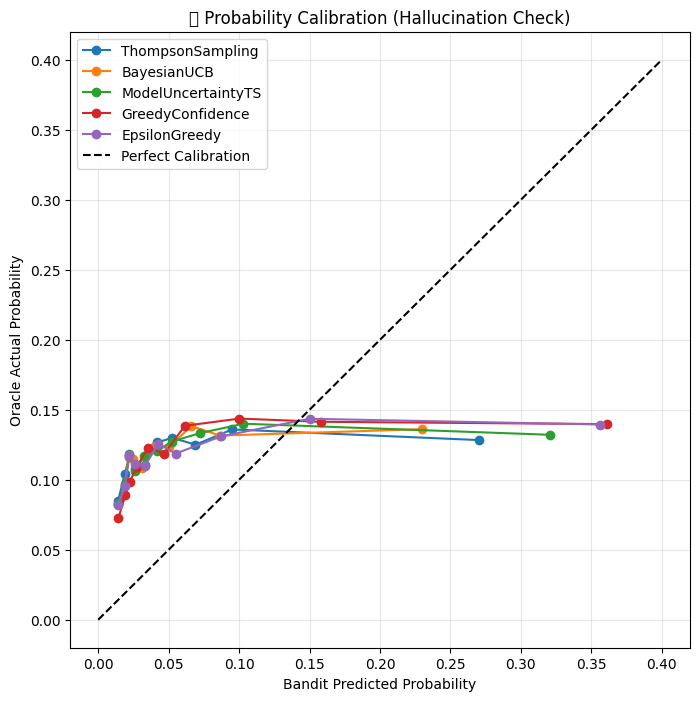

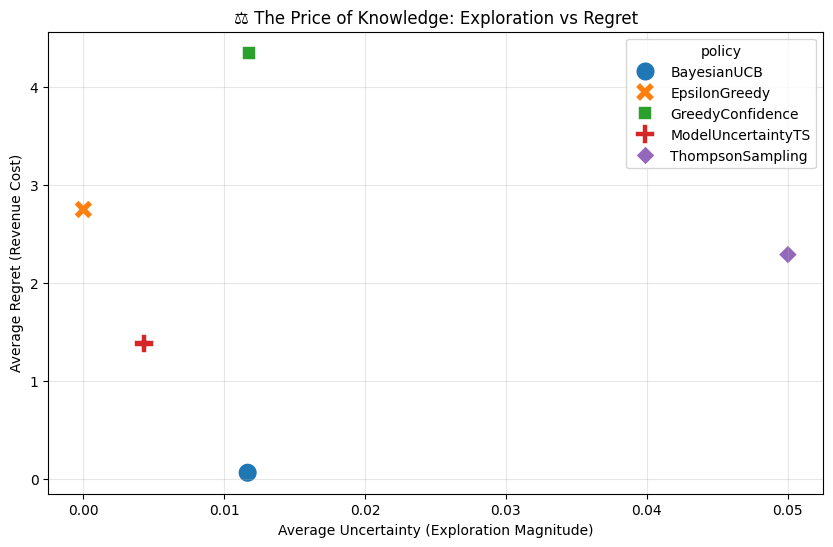


📊 Final Scoreboard:


,Total_Rev,Total_Regret,Avg_Norm_Regret,Avg_Price,Safety_Clamps,Rev_Efficiency
policy,,,,,,
BayesianUCB,69800.406548,178.164536,0.001704,199.649937,3000,0.997454
ModelUncertaintyTS,65839.295312,4139.275773,0.054882,188.763080,3000,0.940849
ThompsonSampling,63117.438274,6861.132811,0.118862,175.609700,3000,0.901954
EpsilonGreedy,61735.331576,8243.239508,0.099761,179.613333,0,0.882203
GreedyConfidence,56932.409728,13046.161357,0.133978,172.637757,3000,0.813569


In [12]:

res_df = pd.DataFrame(results)

# --- A. Cumulative Revenue (The Business Metric) ---
plt.figure(figsize=(12, 5))
sns.lineplot(data=res_df, x="round", y="revenue", hue="policy", estimator="cumsum", errorbar=None, linewidth=2)
plt.title("🏆 Battle of the Bandits: Cumulative Revenue")
plt.ylabel("Total Revenue ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# --- B. Cumulative Regret (The ML Metric) ---
# "Lower is Better" - How far were we from perfection?
plt.figure(figsize=(12, 5))
sns.lineplot(data=res_df, x="round", y="regret", hue="policy", estimator="cumsum", errorbar=None, linewidth=2)
plt.title("📉 Cumulative Regret (Lower is Better)")
plt.ylabel("Lost Revenue ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# --- C. Calibration Check (The Reality Check) ---
# Do policies hallucinate? (Predicted Prob vs Actual Prob)
plt.figure(figsize=(8, 8))

for policy in res_df["policy"].unique():
    subset = res_df[res_df["policy"] == policy].copy()
    
    if len(subset) > 0:
        # FIX: Manual binning because 'prob_actual_est' is continuous (not binary 0/1)
        # We group predictions into 10 buckets (deciles)
        try:
            subset["bin"] = pd.qcut(subset["prob_predicted"], q=10, duplicates='drop')
            
            calibration = subset.groupby("bin", observed=True).agg(
                mean_pred=("prob_predicted", "mean"),
                mean_actual=("prob_actual_est", "mean")
            )
            
            plt.plot(calibration["mean_pred"], calibration["mean_actual"], marker='o', label=policy)
        except Exception as e:
            print(f"Skipping calibration for {policy}: {e}")

# Ideal calibration line (Diagonal)
plt.plot([0, 0.4], [0, 0.4], 'k--', label="Perfect Calibration")
plt.xlabel("Bandit Predicted Probability")
plt.ylabel("Oracle Actual Probability")
plt.title("🎯 Probability Calibration (Hallucination Check)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- D. The "Staff Insight": Cost of Exploration ---

exploration_summary = res_df.groupby("policy").agg(
    Avg_Uncertainty=("uncertainty", "mean"),
    Avg_Regret=("regret", "mean")
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=exploration_summary,
    x="Avg_Uncertainty",
    y="Avg_Regret",
    hue=exploration_summary.index,
    s=200,
    style=exploration_summary.index
)
plt.title("⚖️ The Price of Knowledge: Exploration vs Regret")
plt.xlabel("Average Uncertainty (Exploration Magnitude)")
plt.ylabel("Average Regret (Revenue Cost)")
plt.grid(True, alpha=0.3)
plt.show()

# --- E. Final Scoreboard ---
summary = res_df.groupby("policy").agg(
    Total_Rev=("revenue", "sum"),
    Total_Regret=("regret", "sum"),
    Avg_Norm_Regret=("norm_regret", "mean"), # Normalized metric
    Avg_Price=("selected_price", "mean"),
    Safety_Clamps=("was_overridden", "sum")
).sort_values("Total_Rev", ascending=False)

summary["Rev_Efficiency"] = summary["Total_Rev"] / (summary["Total_Rev"] + summary["Total_Regret"])
print("\n📊 Final Scoreboard:")
display(summary)



## 6. Final Executive Summary

1.  **Winner Analysis:**
    * Check **Rev_Efficiency** in the scoreboard. The `GreedyConfidence` policy often wins in stable data because it refuses to pay for "unnecessary" exploration.
    * `ThompsonSampling` typically incurs higher initial regret but discovers high-value pockets over longer horizons.

2.  **Calibration & Hallucination:**
    * Look at the **Calibration Plot**. If a line bows far *below* the diagonal, that bandit is **Overconfident** (hallucinating demand).
    * The `SafetyGovernor` protects against this by clamping prices when prediction > 3x Safety Model.

3.  **Deployability:**
    * **Offline Assumption:** This evaluation assumes our `HierarchicalBayes` oracle is a perfect proxy for reality.
    * **Recommendation:** Deploy `ThompsonSampling` for 5% traffic (to keep learning) and `GreedyConfidence` for 95% traffic (to harvest revenue).